<a href="https://colab.research.google.com/github/ercenttannius123/Liver-Tumor-Detection/blob/main/Liver%20Tumor%20Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ercenttannius","key":"b46cd255000b60c9ed0d1e09034c2893"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("✅ Kaggle API siap!")

✅ Kaggle API siap!


In [3]:
!kaggle datasets download -d andrewmvd/liver-tumor-segmentation
print("✅ Download selesai!")

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/liver-tumor-segmentation
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 99% 4.77G/4.84G [02:32<00:06, 12.4MB/s]
100% 4.84G/4.84G [02:32<00:00, 34.0MB/s]
✅ Download selesai!


In [4]:
!unzip liver-tumor-segmentation.zip -d /content/dataset
print("✅ Extract selesai!")

Archive:  liver-tumor-segmentation.zip
  inflating: /content/dataset/segmentations/segmentation-0.nii  
  inflating: /content/dataset/segmentations/segmentation-1.nii  
  inflating: /content/dataset/segmentations/segmentation-10.nii  
  inflating: /content/dataset/segmentations/segmentation-100.nii  
  inflating: /content/dataset/segmentations/segmentation-101.nii  
  inflating: /content/dataset/segmentations/segmentation-102.nii  
  inflating: /content/dataset/segmentations/segmentation-103.nii  
  inflating: /content/dataset/segmentations/segmentation-104.nii  
  inflating: /content/dataset/segmentations/segmentation-105.nii  
  inflating: /content/dataset/segmentations/segmentation-106.nii  
  inflating: /content/dataset/segmentations/segmentation-107.nii  
  inflating: /content/dataset/segmentations/segmentation-108.nii  
  inflating: /content/dataset/segmentations/segmentation-109.nii  
  inflating: /content/dataset/segmentations/segmentation-11.nii  
  inflating: /content/dataset

In [5]:
import os

dataset_path = '/content/dataset'
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"{indent}  {f}")

dataset/
  volume_pt4/
    volume-40.nii
    volume-39.nii
    volume-35.nii
  volume_pt3/
    volume-21.nii
    volume-27.nii
    volume-23.nii
  segmentations/
    segmentation-18.nii
    segmentation-116.nii
    segmentation-88.nii
  volume_pt1/
    volume-8.nii
    volume-7.nii
    volume-5.nii
  volume_pt5/
    volume-46.nii
    volume-44.nii
    volume-47.nii
  volume_pt2/
    volume-14.nii
    volume-15.nii
    volume-16.nii


In [6]:
!pip install nibabel -q

import os, cv2, nibabel as nib, numpy as np, torch
import torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import matplotlib.pyplot as plt

DATASET_PATH  = "/content/dataset"
VOLUME_DIRS   = [f"{DATASET_PATH}/volume_pt{i}" for i in range(1, 6)]
SEGMEN_DIR    = f"{DATASET_PATH}/segmentations"
OUT_IMG       = "/content/slices/images"
OUT_MASK      = "/content/slices/masks"

IMG_SIZE      = 128
BATCH_SIZE    = 16
EPOCHS        = 30
LEARNING_RATE = 1e-4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {DEVICE}")

✅ Device: cuda


In [7]:
def convert_all_volumes(volume_dirs, segmen_dir, out_img, out_mask):
    os.makedirs(out_img,  exist_ok=True)
    os.makedirs(out_mask, exist_ok=True)
    saved, skipped = 0, 0

    all_vol_files = []
    for vdir in volume_dirs:
        for f in os.listdir(vdir):
            if f.endswith(".nii"):
                all_vol_files.append(os.path.join(vdir, f))

    print(f"Total volume: {len(all_vol_files)}")

    for vol_path in tqdm(all_vol_files, desc="Konversi NIfTI"):
        fname    = os.path.basename(vol_path)
        num      = fname.replace("volume-", "").replace(".nii", "")
        seg_path = os.path.join(segmen_dir, f"segmentation-{num}.nii")

        if not os.path.exists(seg_path):
            skipped += 1
            continue

        vol_data = nib.load(vol_path).get_fdata()
        seg_data = nib.load(seg_path).get_fdata()

        for i in range(vol_data.shape[2]):
            mask_slice = seg_data[:, :, i]
            if mask_slice.max() == 0:
                continue
            img_slice = vol_data[:, :, i]
            img_clip  = np.clip(img_slice, -150, 250)
            img_norm  = ((img_clip - img_clip.min()) /
                        (img_clip.max() - img_clip.min() + 1e-8) * 255).astype(np.uint8)
            mask_bin  = (mask_slice > 0).astype(np.uint8) * 255
            img_res   = cv2.resize(img_norm,  (IMG_SIZE, IMG_SIZE))
            mask_res  = cv2.resize(mask_bin, (IMG_SIZE, IMG_SIZE),
                                   interpolation=cv2.INTER_NEAREST)
            filename  = f"vol{num}_slice{i:04d}.png"
            cv2.imwrite(os.path.join(out_img,  filename), img_res)
            cv2.imwrite(os.path.join(out_mask, filename), mask_res)
            saved += 1

    print(f"✅ Slice tersimpan: {saved} | Di-skip: {skipped}")

convert_all_volumes(VOLUME_DIRS, SEGMEN_DIR, OUT_IMG, OUT_MASK)

Total volume: 51


Konversi NIfTI: 100%|██████████| 51/51 [01:43<00:00,  2.02s/it]

✅ Slice tersimpan: 6802 | Di-skip: 0


In [9]:
import random
class LiverDataset(Dataset):
    def __init__(self, img_paths, mask_paths):
        self.img_paths  = img_paths
        self.mask_paths = mask_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img  = cv2.imread(self.img_paths[idx],  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
        img  = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)
        img  = torch.tensor(img).unsqueeze(0)
        mask = torch.tensor(mask).unsqueeze(0)
        return img, mask

all_vol_ids = []
for vdir in VOLUME_DIRS:
    for f in os.listdir(vdir):
        if f.endswith(".nii"):
            num = f.replace("volume-", "").replace(".nii", "")
            all_vol_ids.append(num)

random.seed(42)
random.shuffle(all_vol_ids)
split_idx  = int(len(all_vol_ids) * 0.8)
train_vols = set(all_vol_ids[:split_idx])
val_vols   = set(all_vol_ids[split_idx:])
print(f"✅ Train volumes: {len(train_vols)} | Val volumes: {len(val_vols)}")

all_imgs  = sorted([os.path.join(OUT_IMG,  f) for f in os.listdir(OUT_IMG)])
all_masks = sorted([os.path.join(OUT_MASK, f) for f in os.listdir(OUT_MASK)])

X_train, y_train, X_val, y_val = [], [], [], []
for img_path, mask_path in zip(all_imgs, all_masks):
    fname  = os.path.basename(img_path)
    vol_id = fname.split("_")[0].replace("vol", "")
    if vol_id in train_vols:
        X_train.append(img_path)
        y_train.append(mask_path)
    else:
        X_val.append(img_path)
        y_val.append(mask_path)

train_ds     = LiverDataset(X_train, y_train)
val_ds       = LiverDataset(X_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Train: {len(train_ds)} | Val: {len(val_ds)}")

✅ Train volumes: 40 | Val volumes: 11
✅ Train: 5120 | Val: 1682


In [10]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(1, 64);   self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256); self.enc4 = ConvBlock(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(512, 1024)
        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = ConvBlock(1024, 512)
        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)
        self.out  = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return torch.sigmoid(self.out(d1))

model  = UNet().to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f"✅ U-Net siap! Parameters: {params:,} | Device: {DEVICE}")

✅ U-Net siap! Parameters: 31,042,369 | Device: cuda


In [11]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        pred_f   = pred.view(-1)
        target_f = target.view(-1)
        intersection = (pred_f * target_f).sum()
        dice_loss = 1 - (2. * intersection + self.smooth) / \
                        (pred_f.sum() + target_f.sum() + self.smooth)
        bce_loss = nn.BCELoss()(pred, target)
        return dice_loss + bce_loss

def compute_metrics(pred, target, threshold=0.5):
    pred_bin  = (pred > threshold).float()
    pred_np   = pred_bin.cpu().numpy().flatten().astype(int)
    target_np = target.cpu().numpy().flatten().astype(int)
    tn, fp, fn, tp = confusion_matrix(target_np, pred_np, labels=[0,1]).ravel()
    return dict(
        accuracy    = (tp + tn) / (tp + tn + fp + fn + 1e-8),
        precision   = tp / (tp + fp + 1e-8),
        recall      = tp / (tp + fn + 1e-8),
        specificity = tn / (tn + fp + 1e-8),
        dice        = (2 * tp) / (2 * tp + fp + fn + 1e-8),
        jaccard     = tp / (tp + fp + fn + 1e-8),
    )

loss_fn   = DiceBCELoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
print("✅ Loss, Optimizer, Metrics siap!")

✅ Loss, Optimizer, Metrics siap!


In [12]:
history  = {k: [] for k in ["train_loss", "val_loss", "accuracy",
             "precision", "recall", "specificity", "dice", "jaccard"]}
best_dice = 0.0

for epoch in range(EPOCHS):
    # ── Train ────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(imgs), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validation ───────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds = model(imgs)
            val_loss += loss_fn(preds, masks).item()
            all_preds.append(preds)
            all_targets.append(masks)

    val_loss   /= len(val_loader)
    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    metrics     = compute_metrics(all_preds, all_targets)
    scheduler.step(val_loss)

    # ── Simpan history ───────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    for k, v in metrics.items():
        history[k].append(v)

    # ── Print ─────────────────────────────────────────────────
    print(f"\n📊 Epoch {epoch+1}/{EPOCHS}")
    print(f"   Loss        → Train: {train_loss:.4f} | Val: {val_loss:.4f}")
    print(f"   Accuracy    : {metrics['accuracy']:.4f}")
    print(f"   Precision   : {metrics['precision']:.4f}")
    print(f"   Recall      : {metrics['recall']:.4f}")
    print(f"   Specificity : {metrics['specificity']:.4f}")
    print(f"   Dice Score  : {metrics['dice']:.4f}  ← metrik utama")
    print(f"   Jaccard     : {metrics['jaccard']:.4f}")

    if metrics["dice"] > best_dice:
        best_dice = metrics["dice"]
        torch.save(model.state_dict(), "/content/best_unet_liver.pth")
        print(f"   ✅ Model terbaik disimpan! Dice: {best_dice:.4f}")

print(f"\n🎉 Training selesai! Best Dice: {best_dice:.4f}")




Epoch 1/30 [Val]: 100%|██████████| 106/106 [00:07<00:00, 13.68it/s]



📊 Epoch 1/30
   Loss        → Train: 0.9458 | Val: 0.8434
   Accuracy    : 0.9878
   Precision   : 0.8522
   Recall      : 0.9815
   Specificity : 0.9882
   Dice Score  : 0.9123  ← metrik utama
   Jaccard     : 0.8387
   ✅ Model terbaik disimpan! Dice: 0.9123


Epoch 2/30 [Val]: 100%|██████████| 106/106 [00:08<00:00, 12.30it/s]



📊 Epoch 2/30
   Loss        → Train: 0.6685 | Val: 0.6491
   Accuracy    : 0.9925
   Precision   : 0.9246
   Recall      : 0.9621
   Specificity : 0.9946
   Dice Score  : 0.9429  ← metrik utama
   Jaccard     : 0.8920
   ✅ Model terbaik disimpan! Dice: 0.9429


Epoch 3/30 [Val]: 100%|██████████| 106/106 [00:08<00:00, 12.31it/s]


...


📊 Epoch 28/30
   Loss        → Train: 0.0161 | Val: 0.1163
   Accuracy    : 0.9933
   Precision   : 0.9398
   Recall      : 0.9586
   Specificity : 0.9958
   Dice Score  : 0.9491  ← metrik utama
   Jaccard     : 0.9031


Epoch 29/30 [Val]: 100%|██████████| 106/106 [00:08<00:00, 12.27it/s]



📊 Epoch 29/30
   Loss        → Train: 0.0100 | Val: 0.1220
   Accuracy    : 0.9934
   Precision   : 0.9392
   Recall      : 0.9598
   Specificity : 0.9957
   Dice Score  : 0.9494  ← metrik utama
   Jaccard     : 0.9036


Epoch 30/30 [Val]: 100%|██████████| 106/106 [00:08<00:00, 12.27it/s]



📊 Epoch 30/30
   Loss        → Train: 0.0074 | Val: 0.1218
   Accuracy    : 0.9934
   Precision   : 0.9366
   Recall      : 0.9628
   Specificity : 0.9955
   Dice Score  : 0.9495  ← metrik utama
   Jaccard     : 0.9039

🎉 Training selesai! Best Dice: 0.9531


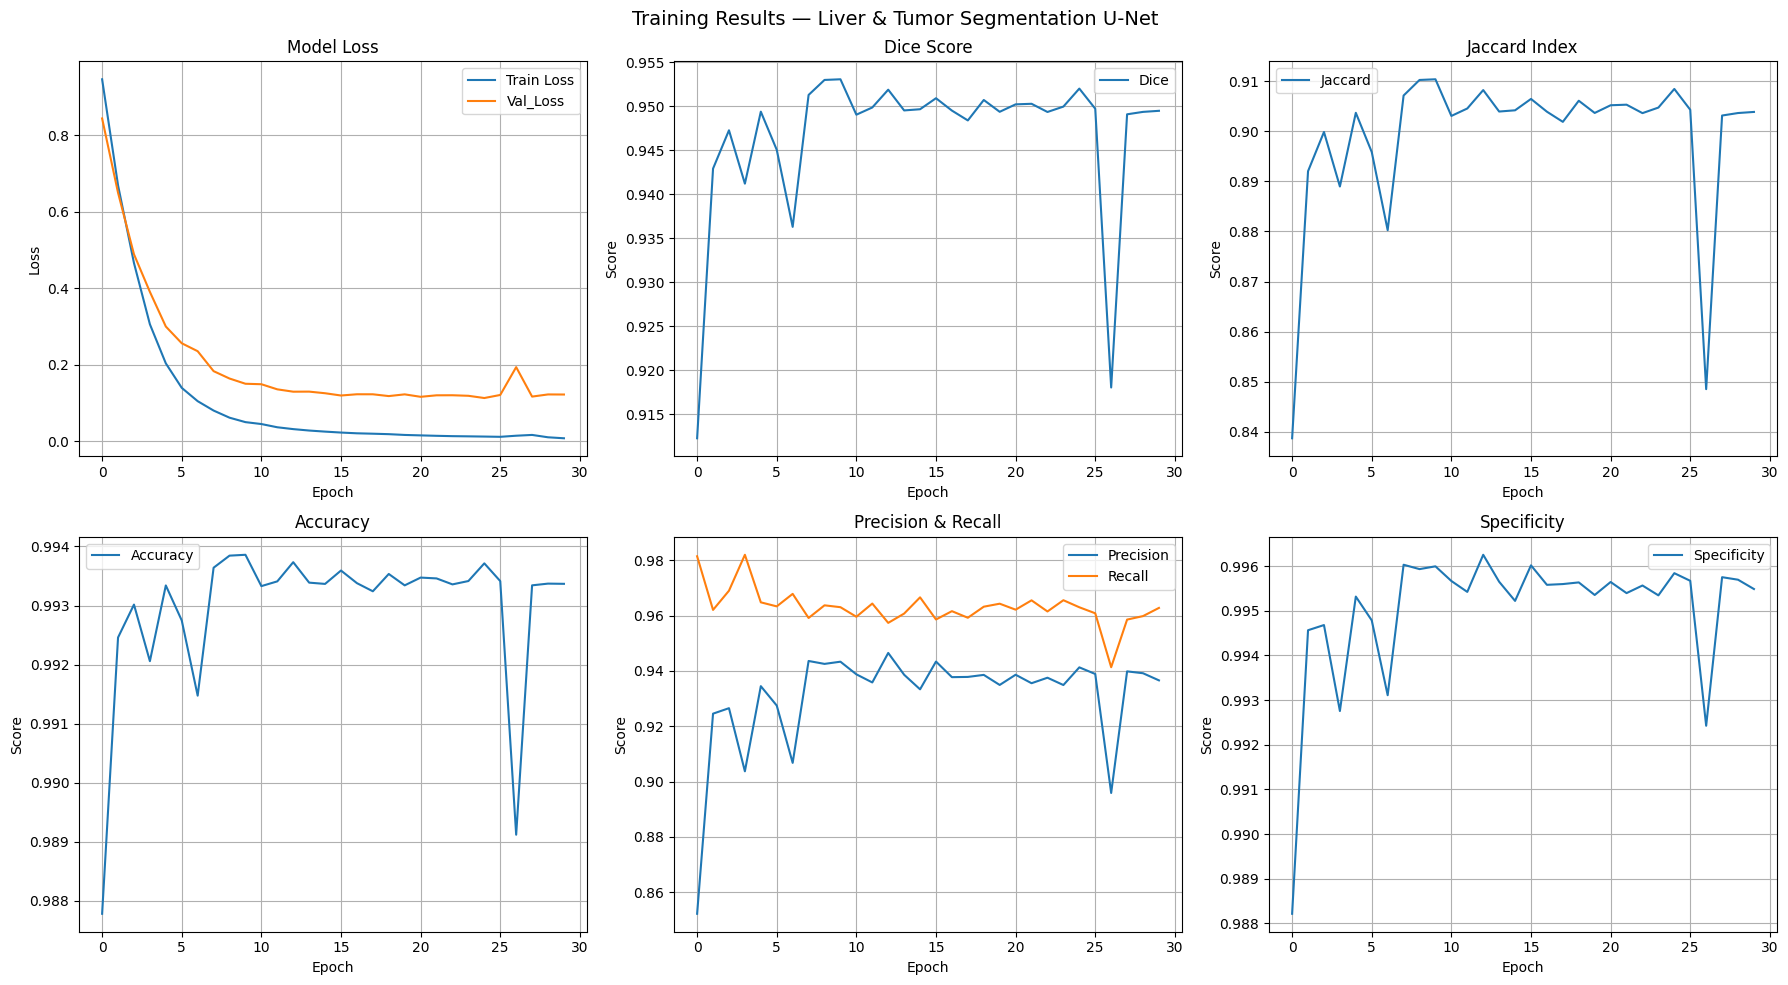

✅ Grafik disimpan!


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training Results — Liver & Tumor Segmentation U-Net", fontsize=14)

metrics_plot = [
    ("train_loss",  "val_loss",  "Model Loss",        "Loss"),
    ("dice",         None,       "Dice Score",        "Score"),
    ("jaccard",      None,       "Jaccard Index",     "Score"),
    ("accuracy",     None,       "Accuracy",          "Score"),
    ("precision",   "recall",   "Precision & Recall", "Score"),
    ("specificity",  None,       "Specificity",       "Score"),
]

for ax, (m1, m2, title, ylabel) in zip(axes.flatten(), metrics_plot):
    ax.plot(history[m1], label=m1.replace("_"," ").title())
    if m2:
        ax.plot(history[m2], label=m2.title())
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("/content/training_results.png", dpi=150)
plt.show()
print("✅ Grafik disimpan!")

In [14]:
model.load_state_dict(torch.load("/content/best_unet_liver.pth"))
model.eval()

final_preds, final_targets = [], []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs)
        final_preds.append(preds)
        final_targets.append(masks.to(DEVICE))

final_preds   = torch.cat(final_preds)
final_targets = torch.cat(final_targets)
m = compute_metrics(final_preds, final_targets)

print("\n" + "="*50)
print("  HASIL EVALUASI FINAL — U-Net Liver & Tumor")
print("="*50)
print(f"  {'Accuracy':<15} : {m['accuracy']:.4f}")
print(f"  {'Precision':<15} : {m['precision']:.4f}")
print(f"  {'Recall':<15} : {m['recall']:.4f}")
print(f"  {'Specificity':<15} : {m['specificity']:.4f}")
print(f"  {'Dice Score':<15} : {m['dice']:.4f}  ← utama")
print(f"  {'Jaccard Index':<15} : {m['jaccard']:.4f}")
print("="*50)


  HASIL EVALUASI FINAL — U-Net Liver & Tumor
  Accuracy        : 0.9939
  Precision       : 0.9433
  Recall          : 0.9630
  Specificity     : 0.9960
  Dice Score      : 0.9531  ← utama
  Jaccard Index   : 0.9104


Large liver samples : 406
Medium liver samples: 780
Small tumor samples : 463
Selected indices: [929, 435, 900, 119, 1044]


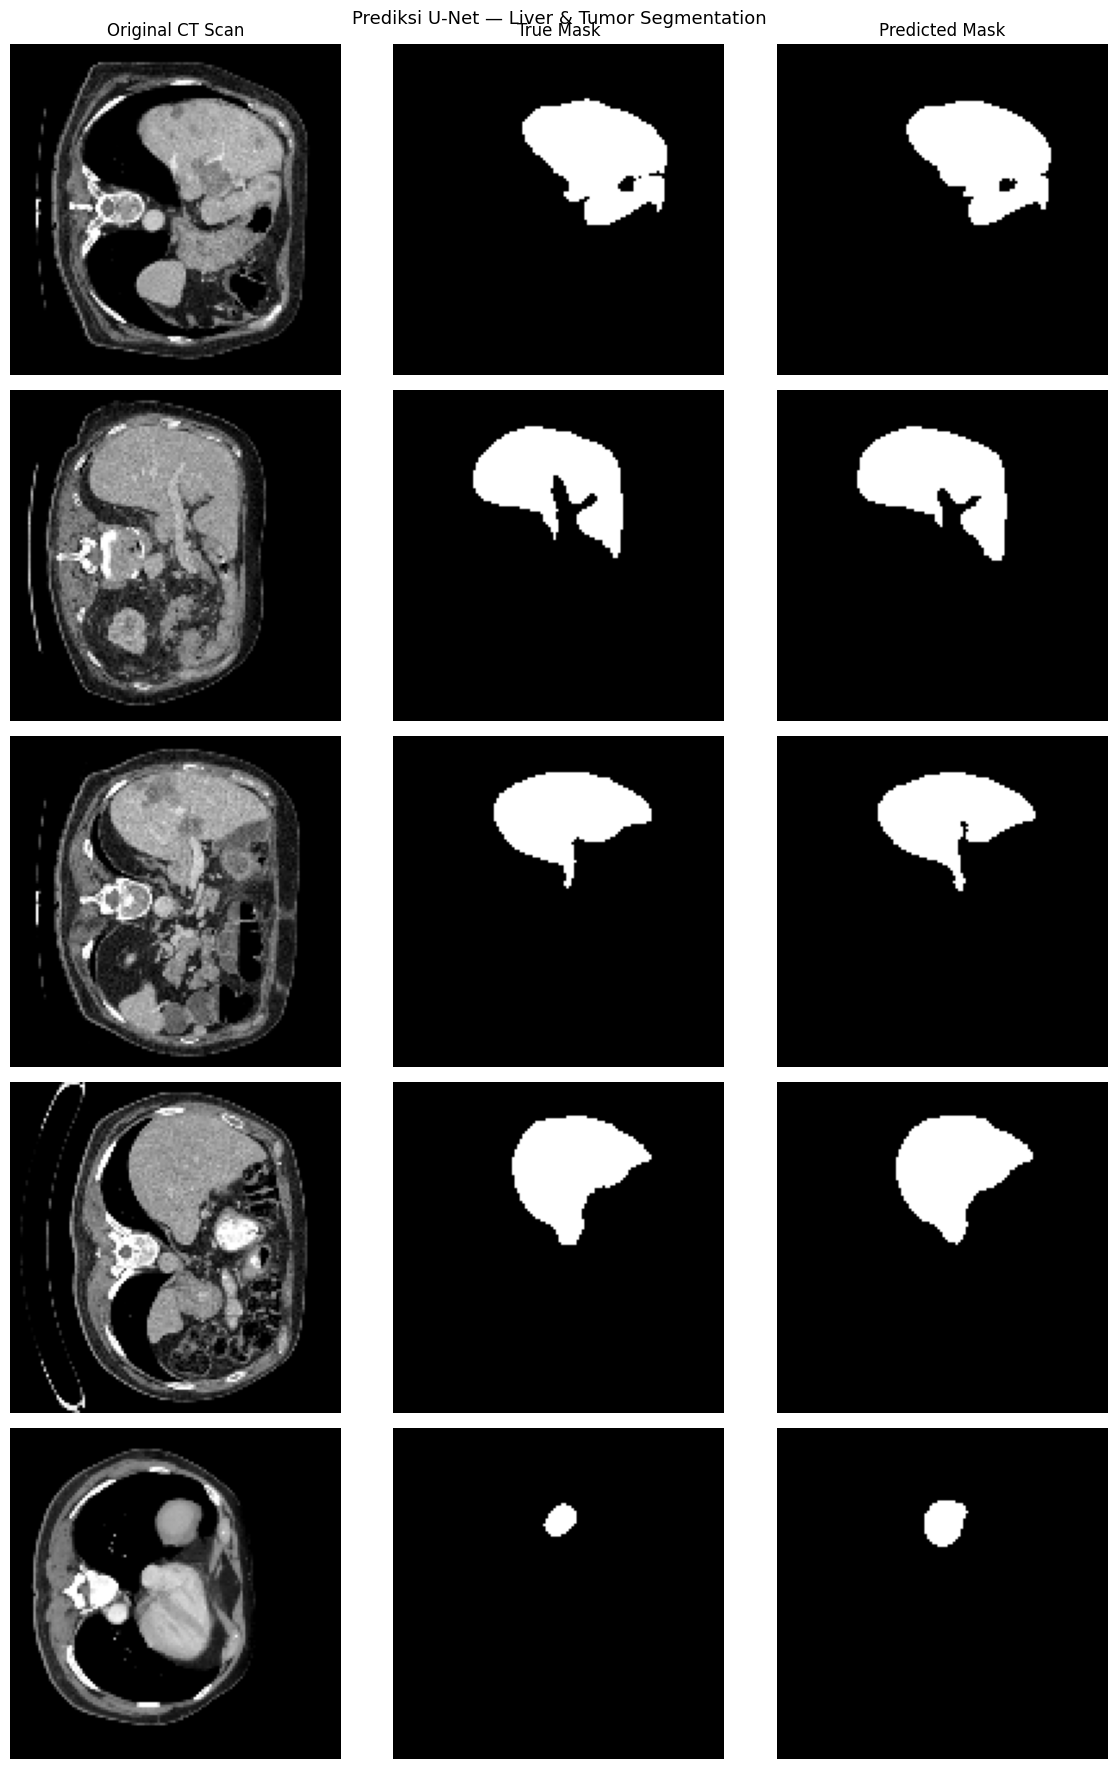

✅ Visualisasi representatif disimpan!


In [17]:
model.eval()

# Kumpulkan SEMUA validation samples dulu
all_imgs_val = []
all_masks_val = []
all_preds_val = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs)
        all_imgs_val.append(imgs.cpu())
        all_masks_val.append(masks.cpu())
        all_preds_val.append(preds.cpu())

all_imgs_val  = torch.cat(all_imgs_val)
all_masks_val = torch.cat(all_masks_val)
all_preds_val = torch.cat(all_preds_val)

# Hitung foreground ratio tiap sample
fg_ratios = all_masks_val.squeeze().mean(dim=(1,2))

# Pilih sample berdasarkan kategori
large_liver  = (fg_ratios > 0.10).nonzero(as_tuple=True)[0]
medium_liver = ((fg_ratios > 0.03) & (fg_ratios <= 0.10)).nonzero(as_tuple=True)[0]
small_tumor  = ((fg_ratios > 0.001) & (fg_ratios <= 0.03)).nonzero(as_tuple=True)[0]

print(f"Large liver samples : {len(large_liver)}")
print(f"Medium liver samples: {len(medium_liver)}")
print(f"Small tumor samples : {len(small_tumor)}")

# Ambil 2 large, 2 medium, 1 small
import random
selected = []
if len(large_liver)  >= 2: selected += random.sample(large_liver.tolist(),  2)
elif len(large_liver) >= 1: selected += large_liver.tolist()[:1]
if len(medium_liver) >= 2: selected += random.sample(medium_liver.tolist(), 2)
elif len(medium_liver) >= 1: selected += medium_liver.tolist()[:1]
if len(small_tumor)  >= 1: selected += random.sample(small_tumor.tolist(),  1)

selected = selected[:5]
print(f"Selected indices: {selected}")

# Plot
fig, axes = plt.subplots(5, 3, figsize=(12, 18))
fig.suptitle("Prediksi U-Net — Liver & Tumor Segmentation", fontsize=13)

for row, idx in enumerate(selected):
    img  = all_imgs_val[idx].squeeze().numpy()
    mask = all_masks_val[idx].squeeze().numpy()
    pred = (all_preds_val[idx].squeeze().numpy() > 0.5).astype(float)

    fg = mask.mean() * 100
    for col, (data, title) in enumerate(zip(
        [img, mask, pred],
        ["Original CT Scan", "True Mask", "Predicted Mask"]
    )):
        axes[row][col].imshow(data, cmap="gray")
        if col == 0:
            axes[row][col].set_ylabel(f"Sample {row+1}\n(FG:{fg:.1f}%)", fontsize=8)
        axes[row][col].set_title(title if row == 0 else "")
        axes[row][col].axis("off")

plt.tight_layout()
plt.savefig("/content/prediction_samples.png", dpi=150)
plt.show()
print("✅ Visualisasi representatif disimpan!")

In [18]:
from google.colab import files
files.download("/content/training_results.png")
files.download("/content/prediction_samples.png")
files.download("/content/best_unet_liver.pth")
print("✅ Semua file ter-download!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Semua file ter-download!
